## Introduction

The following is Random Forest Classifier made with the intent of detecting exoplanets using the transit method, where the brightness of stars is measured over time to detect the periodic dimming caused by a planet passing in front of its host star.

#### The Data

The model is trained on the Cumulative Kepler Objects of Interest (KOI) data set provided by the NASA Exoplanet Science Institute, consisting of over 9500 Threshold Crossing Events (TCEs) detected by NASA's Kepler Space Telescope. Threshold Crossing Events (TCEs) are periodic signals in Kepler's photometry that exceed a detection Threshold and are flagged as potential planet transits

#### Model Training

It was deliberately trained without the koi_fpflag_* columns which are human-derived flags that directly veto specific known false positive scenarios such as eclipsing binaries and stray light contamination. This means the model identifies candidates purely from the physics of the light curve, making it capable of flagging candidates that human vetting pipelines may have incorrectly dismissed.

The following pipeline covers data preprocessing, feature selection, hyperparameter tuning via GridSearchCV, model evaluation, and model export for streamlit integration.



### Data Preprocessing and Loading

The orignal dataset available on the NASA website has several columns which are either not required for model training or have a format incompatible for model input. These were excluded when downloading the data. 

We exclude other columns like koi_fpflag_* for reasons mentioned in Model Training. The model is deliberately trained without these flags for reasons discussed in the introduction. Typical accuracies of models that include these flags are above 95%. TThe aim is to achieve comparable accuracy. 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import roc_curve, auc
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from joblib_progress import joblib_progress

Data = pd.read_csv('data.csv')
x = Data.drop(columns = ['loc_rowid','koi_pdisposition','koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec'])
x

,koi_period,koi_time0bk,koi_eccen,koi_impact,koi_duration,koi_depth,koi_ror,koi_srho,koi_prad,koi_sma,...,koi_fwm_srao,koi_fwm_sdeco,koi_fwm_prao,koi_fwm_pdeco,koi_dicco_mra,koi_dicco_mdec,koi_dicco_msky,koi_dikco_mra,koi_dikco_mdec,koi_dikco_msky
0,9.488036,170.538750,0.0,0.146,2.95750,615.8,0.022344,3.20796,2.26,0.0853,...,0.430,0.940,-0.000200,-0.000550,-0.010,0.200,0.200,0.080,0.310,0.320
1,54.418383,162.513840,0.0,0.586,4.50700,874.8,0.027954,3.02368,2.83,0.2734,...,-0.630,1.230,0.000660,-0.001050,0.390,0.000,0.390,0.490,0.120,0.500
2,19.899140,175.850252,0.0,0.969,1.78220,10829.0,0.154046,7.29555,14.60,0.1419,...,-0.021,-0.038,0.000700,0.000600,-0.025,-0.034,0.042,0.002,-0.027,0.027
3,1.736952,170.307565,0.0,1.276,2.40641,8079.2,0.387394,0.22080,33.46,0.0267,...,-0.111,0.002,0.003020,-0.001420,-0.249,0.147,0.289,-0.257,0.099,0.276
4,2.525592,171.595550,0.0,0.701,1.65450,603.3,0.024064,1.98635,2.75,0.0374,...,-0.010,0.230,0.000080,-0.000070,0.030,-0.090,0.100,0.070,0.020,0.070
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9559,0.527699,131.705093,0.0,1.252,3.22210,1579.2,0.297633,0.16318,29.35,0.0128,...,0.792,-0.484,-0.000237,0.000178,2.132,-1.757,2.763,2.344,-1.756,2.929
9560,1.739849,133.001270,0.0,0.043,3.11400,48.5,0.006379,0.50770,0.72,0.0290,...,0.100,2.000,-0.000018,-0.000074,0.740,-0.250,0.780,0.500,-0.180,0.530
9561,0.681402,132.181750,0.0,0.147,0.86500,103.6,0.009444,8.97692,1.07,0.0157,...,7.200,-5.600,-0.000720,0.000500,3.410,-3.650,5.000,3.380,-3.890,5.160
9562,333.486169,153.615010,0.0,0.214,3.19900,639.1,0.022590,85.88623,19.30,1.2233,...,0.310,0.010,-0.000290,-0.000100,1.061,1.320,1.690,1.450,1.370,2.000


"koi_pdisposition" is the target variable that tells us whether a certain observation is a potential Candidate or a False Positive. The values are strings and are thus binary encoded. Finally, a stratified train/test split is used to ensure both sets maintain the same class distribution as the original dataset, preventing either split from being disproportionately skewed toward one class. 

In [ ]:
y = Data['koi_pdisposition']
encode = {"CANDIDATE":1, "FALSE POSITIVE":0}
y_encoded = y.map(encode)
x_train, x_test, y_train, y_test = train_test_split(x, y_encoded, test_size=0.25, stratify= y_encoded)

y_encoded

0       1
1       1
2       1
3       0
4       1
       ..
9559    0
9560    1
9561    0
9562    1
9563    0
Name: koi_pdisposition, Length: 9564, dtype: int64

### Initial Model Training

A pipeline was used to ensure the imputation step is fitted only on training data during each cross-validation fold, preventing data leakage into the validation set. This pipeline consists of two steps:

1. Median Imputation: The missing values were filled using an imputation step. Certain values in the dataset are extreme outliers which can provide a skewed mean. The median is used in its stead to overcome this problem.

2. Training: Random Forest Classifier trained through GridSearchCV using a parameter grid.

The parameter grid was designed to balance search coverage with computational cost, especially when I have a machine of - let's just say - painfully constrained ability. The model is finally fitted on training data and the encoded target.

In [ ]:
pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('classifier', RandomForestClassifier(n_jobs=2))
])

param_grid = {
    'classifier__n_estimators' : [100,200,300,400,500],
    'classifier__max_depth' : [5,7,9],
    'classifier__min_samples_leaf': [5,10,15],
    'classifier__max_features': ["sqrt","log2"]
}

GSCV  = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=5, n_jobs=4, verbose=0)

with joblib_progress(description="Training Models", total = 450):
    GSCV.fit(x_train,y_train)

The best model found through GridSearchCV is tested on the testing data and the performance metrics are printed.

In [102]:
print("Best Parameters: ", GSCV.best_params_ )
print("Best Score: ", GSCV.best_score_)

best_model = GSCV.best_estimator_
y_pred = best_model.predict(x_test)
print("Accuracy: ", accuracy_score(y_test,y_pred))

Best Parameters:  {'classifier__max_depth': 9, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 5, 'classifier__n_estimators': 300}
Best Score:  0.8859620272233805
Accuracy:  0.8887494772061899


The accuracy of the model obtained on the test data, and the best score from the Grid Search shows that the model is not overfitted. 

It is important to note that almost all the Best Parameters are at the boundary of the search space. We thus expand the search to find the optimum parameters. 

Since max_features and min_samples_leaf were already confirmed by the initial search, only max_depth and n_estimators need to be expanded in the focused search. Due to computational limitations, only the search for max_depth is expanded.

In [ ]:
pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('classifier', RandomForestClassifier(n_jobs=2))
])

param_grid = {
    'classifier__n_estimators' : [300],
    'classifier__max_depth' : [9,11,13,15],
    'classifier__min_samples_leaf': [5],
    'classifier__max_features': ["sqrt"]
}

GSCV  = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=5, n_jobs=4, verbose=0)

with joblib_progress(description="Training Models", total = 20):
    GSCV.fit(x_train,y_train)

The best model found through GridSearchCV is tested on the testing data and the performance metrics are printed along with the classification report.

In [ ]:
print("Best Parameters: ", GSCV.best_params_ )
print("Best Score: ", GSCV.best_score_)

best_model = GSCV.best_estimator_
y_pred = best_model.predict(x_test)
print("Accuracy: ", accuracy_score(y_test,y_pred))

Best Parameters:  {'classifier__max_depth': 13, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 5, 'classifier__n_estimators': 300}
Best Score:  0.8939085135023497
Accuracy:  0.8929318276871602


In [117]:
print("Classification Report: ")
print(classification_report(y_test,y_pred, target_names=encode.keys()))

Classification Report: 
                precision    recall  f1-score   support

     CANDIDATE       0.89      0.90      0.89      1212
FALSE POSITIVE       0.90      0.89      0.89      1179

      accuracy                           0.89      2391
     macro avg       0.89      0.89      0.89      2391
  weighted avg       0.89      0.89      0.89      2391



### Feature Importance and Selection

Feature selection was perfomed to train a final model. The intetion is to deploy the model using streamlit such that the user can obtain a prediction with the least ammount of features. This improves usability while maintaining or improving model accuracy by reducing noise from uninformative features

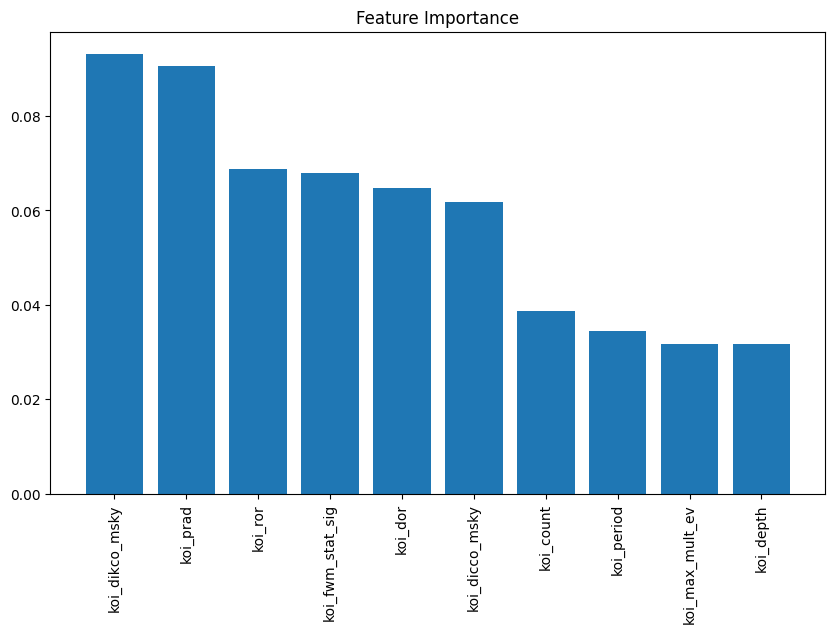

In [ ]:
model = best_model.named_steps['classifier']
Importance = model.feature_importances_
Indices = np.argsort(Importance)[::-1]
TopIndices = Indices[:10]

plt.figure(figsize=(10,6))
plt.title("Feature Importance")
plt.bar(range(10), Importance[TopIndices], align="center")
plt.xticks(range(10), x_train.columns[TopIndices], rotation=90)

plt.show()

There was a natural drop in feature importance after the top 6 features. The top 10 (excluding koi_count)were selected rather than 6 to retain additional signal and reduce the risk of underfitting due to decreased complexity. 

There is also the issue of misleading rankings due to important but correlated features which might mean we discard other important features. koi_count is excluded because it is a catalog property rather than an observation.

Furthurmore, it was noticed that most of the missing values from the selected feature columns were from the same observations. In that case we drop the rows that contain these missing values instead of using the imputer. 

In [160]:

data_selected = Data.dropna(subset=['koi_dikco_msky','koi_prad','koi_ror','koi_fwm_stat_sig','koi_dor','koi_dicco_msky','koi_period','koi_max_mult_ev','koi_depth','koi_max_sngle_ev'])

x_selected = data_selected[['koi_dikco_msky','koi_prad','koi_ror','koi_fwm_stat_sig','koi_dor','koi_dicco_msky','koi_period','koi_max_mult_ev','koi_depth','koi_max_sngle_ev']]

y_selected = data_selected['koi_pdisposition']
encode = {"CANDIDATE":1, "FALSE POSITIVE":0}
y_encoded_selected = y_selected.map(encode)

x_train_selected, x_test_selected, y_train_selected, y_test_selected = train_test_split(x_selected, y_encoded_selected, test_size=0.25, stratify= y_encoded_selected)

### Final Model Training

While training the model the pipeline does not include the imputaion step, as the rows that contained null value were already removed during the selection stage. Note that the Streamlit deployment assumes the user provides complete observations when using the model. The Random Forest Classifier is now trained on balanced class weight to reduce class bias. 

In [ ]:
pipeline = Pipeline(steps=[
    ('classifier', RandomForestClassifier(n_jobs=2, class_weight='balanced'))
])

param_grid = {
    'classifier__n_estimators' : [100,200,300,400,500],
    'classifier__max_depth' : [5,7,9],
    'classifier__min_samples_leaf': [5,10,15],
    'classifier__max_features': ["sqrt","log2"]
}

GSCV_New  = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=5, n_jobs=4, verbose=0)

with joblib_progress(description="Training Models", total = 450):
    GSCV_New.fit(x_train_selected,y_train_selected)


It is evident from the accuracy and performance metrics of the model that it has improved when trained on a selected set of features rather than the entire dataset. This is most likely due to the noise or random patterns from features at the lower end of the importance spectrum being removed.

In [170]:
print("Best Parameters: ", GSCV_New.best_params_ )
print("Best Score: ", GSCV_New.best_score_)

best_model = GSCV_New.best_estimator_
y_pred = best_model.predict(x_test_selected)
print("Accuracy: ", accuracy_score(y_test_selected,y_pred))

Best Parameters:  {'classifier__max_depth': 9, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 5, 'classifier__n_estimators': 200}
Best Score:  0.9158460161145927
Accuracy:  0.9156820622986036


### Model Evaluation

The negligible gap between the cross-validated best score of 0.9158 and a test accuracy of 0.9157 confirms the model generalizes well to unseen data.

Apart from the increased accuracy, we also observe increased scores on all metrics over the initial model. It is also important to note that the model obtains a recall of 0.89 on Candidates. In the context of exoplanet detection, recall for Candidate is very significant as missing a Candidate means a potentially undiscovered planet might go unflagged. 


In [171]:
print("Classification Report: ")
print(classification_report(y_test_selected,y_pred, target_names=encode.keys()))

Classification Report: 
                precision    recall  f1-score   support

     CANDIDATE       0.92      0.89      0.91       853
FALSE POSITIVE       0.91      0.93      0.92      1009

      accuracy                           0.92      1862
     macro avg       0.92      0.91      0.91      1862
  weighted avg       0.92      0.92      0.92      1862



As visible from the ROC curve and the AUC, the model obtains an AUC of 0.972, which indicates that the model can effectively rank a true planetary candidate above a false positive 97.2% of the time, across all possible classification thresholds.

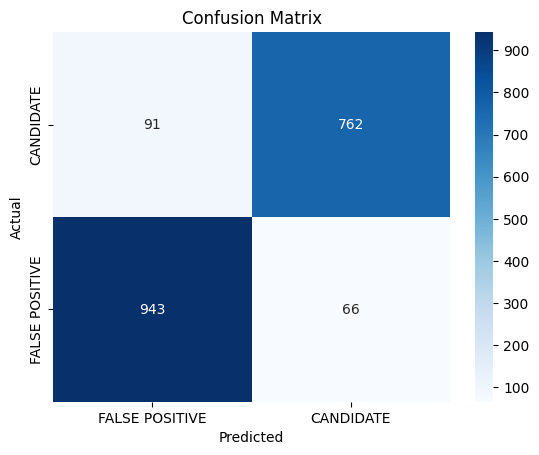

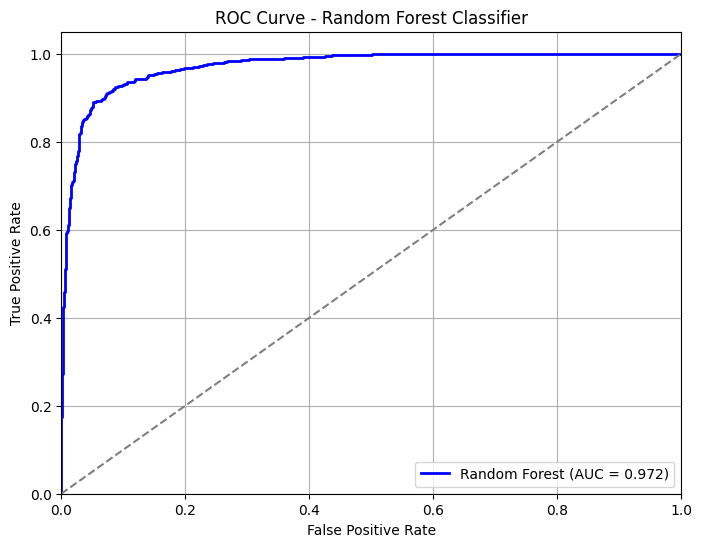

In [ ]:
y_prob = GSCV_New.predict_proba(x_test_selected)[:, 1]
fpr,tpr,thresholds = roc_curve(y_test_selected,y_prob)
roc_auc = auc(fpr,tpr)

cm = confusion_matrix(y_test_selected, y_pred)
ax = sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=encode.keys(), yticklabels=encode.keys())
ax.invert_xaxis()
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"Random Forest (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], color="gray", linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest Classifier")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Model Export

We export the final best_estimator obtained through GridSearchCV along with a list of selected model features, so that they may be accessed during the streamlit deployment. 

The feature list is saved separately to ensure the Streamlit application accepts inputs in the exact order and format the model was trained on, preventing any feature mismatch during inference.

In [173]:
import joblib

joblib.dump(best_model, "Model.pkl")

['Model.pkl']

In [ ]:
feature_list = x_selected.columns.tolist()

joblib.dump(feature_list, 'Model_Features.pkl')

['Model_Features.pkl']